# Detecting Tipping Points with Ammonyte LERM Method

_Description:_ Detect regime shifts in paleoclimate time series using LERM (Laplacian Eigenmaps of Recurrence Matrices) and validate detections against known Dansgaard-Oeschger events.


## Overview

This notebook demonstrates the application of the **LERM (Laplacian Eigenmaps of Recurrence Matrices)** from the [Ammonyte](https://github.com/LinkedEarth/Ammonyte) package for detecting abrupt climate transitions in paleoclimate time series. LERM uses **Fisher Information** to identify rapid shifts in Earth's climate system.

## Scientific Background

### What is LERM?
The **Laplacian Eigenmaps of Recurrence Matrices (LERM)** is a nonlinear time series analysis technique that:
- Converts time series data into a **time-embedded phase space** using delay embedding
- Constructs a **recurrence network** to capture temporal dependencies
- Computes **Fisher Information** through Laplacian eigenmaps
- Detects transitions by identifying when Fisher Information crosses confidence bounds

## Reference

James, A., Emile-Geay, J., Malik, N., & Khider, D. (2024). Detecting Paleoclimate Transitions With Laplacian Eigenmaps of Recurrence Matrices (LERM). *Paleoceanography and Paleoclimatology*. https://doi.org/10.1029/2023PA004700

In [37]:
# Import libraries and packages
import ammonyte as amt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy 

### Load the NGRIP Dataset for Tipping Point Analysis

### Dataset Overview
The **North Greenland Ice Core Project (NGRIP)** dataset contains high-resolution paleoclimate proxy data from Greenland ice cores. This dataset is particularly valuable for studying abrupt climate transitions and tipping points in the Earth's climate system.

**Key Dataset Features:**
- **Proxy Variable**: $\mathrm{\delta^{18}O}$ isotope measurements
- **Units**: per mil
- **Time Scale**: Thousands of years before present (kyr b2k)

In [38]:
ngrip = amt.Series.from_csv('../ammonyte/data/NGRIP.csv')

Time axis values sorted in ascending order
Time axis values sorted in ascending order


In [39]:
# Store original arrays for reuse
ngrip_time_original = ngrip.time.copy()
ngrip_value_original = ngrip.value.copy()

### Dataset Metadata Summary

Display key metadata information from the loaded NGRIP time series to understand the dataset characteristics.

In [40]:
# The metadata
print(f"Loaded NGRIP dataset: {ngrip.label}")
print(f"Time range: {ngrip.time.min():.2f} - {ngrip.time.max():.2f} {ngrip.time_unit}")
print(f"Number of data points: {len(ngrip.time)}")
print(f"Value range: {ngrip.value.min():.2f} - {ngrip.value.max():.2f} {ngrip.value_unit}")

Loaded NGRIP dataset: NGRIP Ice Core Data
Time range: 0.05 - 122.27 kyr b2k
Number of data points: 6112
Value range: -46.50 - -32.11 ‰


### NGRIP $\mathrm{\delta^{18}O}$ Record Visualization
The plot below shows the complete NGRIP ice core record, where:
- **X-axis**: Time in thousands of years before present (kyr b2k)
- **Y-axis**: $\mathrm{\delta^{18}O}$ isotope values in per mil 
- **Interpretation**: More negative values indicate colder conditions

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Age [kyr b2k]', ylabel='δ¹⁸O [‰]'>)

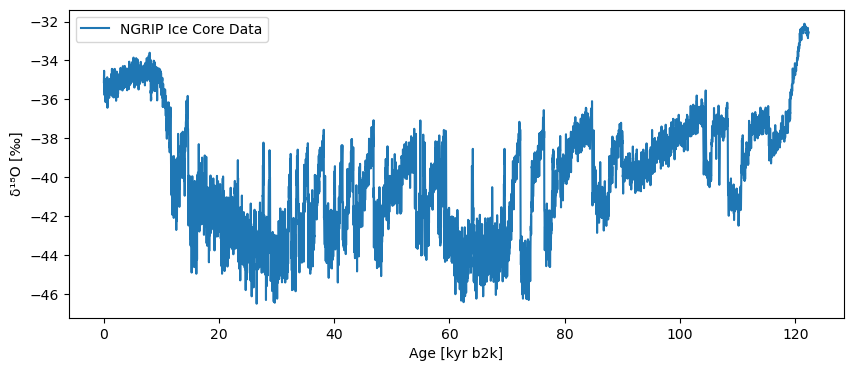

In [41]:
# Plot NGRIP series
ngrip.plot() 

# Main LERM Analysis

This section demonstrates the complete LERM workflow for detecting climate transitions in the NGRIP dataset. We use **block_size=2** for smoothing Fisher Information throughout this analysis.

**Workflow Steps:**
1. Time Delay Embedding - Transform 1D time series into multi-dimensional phase space
2. Recurrence Network Construction - Build network representation of climate dynamics
3. Fisher Information Computation - Extract dynamical information via Laplacian Eigenmaps
4. Smoothing - Apply block averaging to reduce noise (block_size=2)
5. Visualization - Display smoothed Fisher Information
6. Transition Detection - Apply LERM method to identify climate transitions
7. Results Visualization - Show detected transitions on both Fisher Information and NGRIP data
8. Alternative Method - Apply KS test for comparison

## Step 1: Time Delay Embedding

#### Phase Space Reconstruction
To apply the LERM method, we first transform the 1-dimensional time series into a **multi-dimensional phase space**.

**Key Parameters:**
- **`m` (embedding dimension)**: The number of dimensions in the reconstructed phase space
- **`tau` (time delay)**: The lag between successive coordinates in the embedded space
    - Automatically computed to optimize reconstruction
    - Represents the decorrelation timescale of the system

In [42]:
#series to time embedded series
m = 12
NGRIP_td = amt.TimeEmbeddedSeries(ngrip , m)
NGRIP_td.tau

9

## Step 2: Recurrence Network Construction
#### Finding the Optimal Epsilon Parameter
Before constructing the recurrence network, we need to determine the optimal **epsilon (ε)** value, which defines the neighborhood radius for connecting points in the phase space. The algorithm iteratively adjusts epsilon until the recurrence network 
  achieves the target density.

**Method:** Adaptive epsilon search to achieve target network density

**Parameters:**
- **`eps`**: Initial epsilon value to start the search (1.0)
- **`target_density`**: Desired density of the recurrence network (0.05 = 5\%)
- **`tolerance`**: Acceptable deviation from target density (0.01 = 1\%, meaning it Stops search when density is within [4\%, 6\%])
- **`amp`**: Amplitude scaling factor for the search (30, Controls the step size during epsilon optimization)


In [43]:
NGRIP_epsilon = NGRIP_td.find_epsilon(eps=1,target_density=.05,tolerance=.01,amp=30)

Initial density is 0.0003
Initial density is not within the tolerance window, searching...
Epsilon: 2.4915, Density: 0.0126
Epsilon: 3.6123, Density: 0.0335
Epsilon: 4.1062, Density: 0.0464
Epsilon: 4.1062, Density: 0.0464.


### Recurrence Matrices Visualization
#### Extracting and Visualizing the Recurrence Network

**What is a Recurrence Matrices?**
- A binary Matrices where entry (i,j) = 1 if points i and j are "close" in phase space (within epsilon distance)

**Interpretation**
- **Dense black regions**: Stable climate states with high recurrence
  (stadials or interstadials)
- **White/sparse regions**: Transitional periods, rapid changes, or unique states **Tipping points occur here**
- **Black diagonal lines**: Similar evolution patterns at different times
- **Black vertical/horizontal lines**: Frequently recurring climate states

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Recurrence Matrices'}, xlabel='Age kyr b2k', ylabel='Age kyr b2k'>)

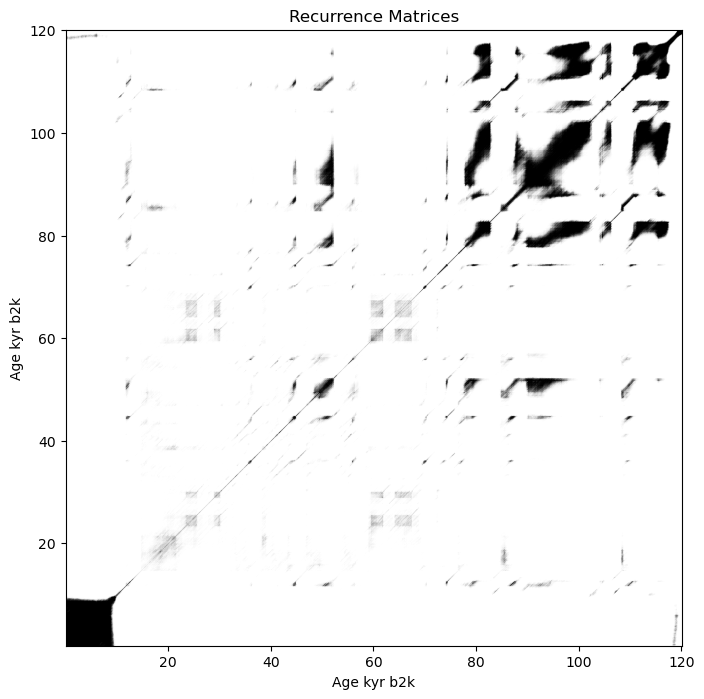

In [44]:
NGRIP_rm = NGRIP_epsilon['Output']
# plot the recurrence Matrices
NGRIP_rm.plot(title = 'Recurrence Matrices')

## Step 3: Fisher Information Computation
#### Extracting Dynamical Information from the Recurrence Network
The **Laplacian Eigenmaps** method computes **Fisher Information** from
the recurrence network using a sliding window approach. Fisher Information quantifies how much information the system's trajectory carries about its underlying dynamics and serves as an early warning signal for tipping points.

**Parameters:**
- **`w_size`**: Window size (20 time steps)
    - Size of the sliding window for local Fisher Information computation
- **`w_incre`**: Window increment (4 time steps)
    - Step size for moving the window along the time series

**Fisher Information Interpretation:**
  - **High Fisher Information**: System is near a critical transition
  - **Low Fisher Information**: System is stable

In [45]:
NGRIP_lp = NGRIP_rm.laplacian_eigenmaps(w_size=20,w_incre=4)

## Step 4: Smoothing the Fisher Information Series

The raw Fisher Information signal can contain high-frequency noise that may lead to false positive transition detections. We apply **block averaging** to smooth the series while preserving the timing and magnitude of genuine transitions.

**Method:** Block averaging with sliding window

**Parameters:**
- **`block_size`**: Size of the averaging window (2 time steps)

In [46]:
NGRIP_lp_smooth = amt.utils.fisher.smooth_series(series=NGRIP_lp, block_size=2)

## Step 5: Visualizing Smoothed Fisher Information

This visualization displays the **smoothed Fisher Information**.

**Plot elements:**
- **Blue line**: Smoothed Fisher Information signal
- **X-axis**: Time in kyr b2k
- **Y-axis**: Fisher Information values

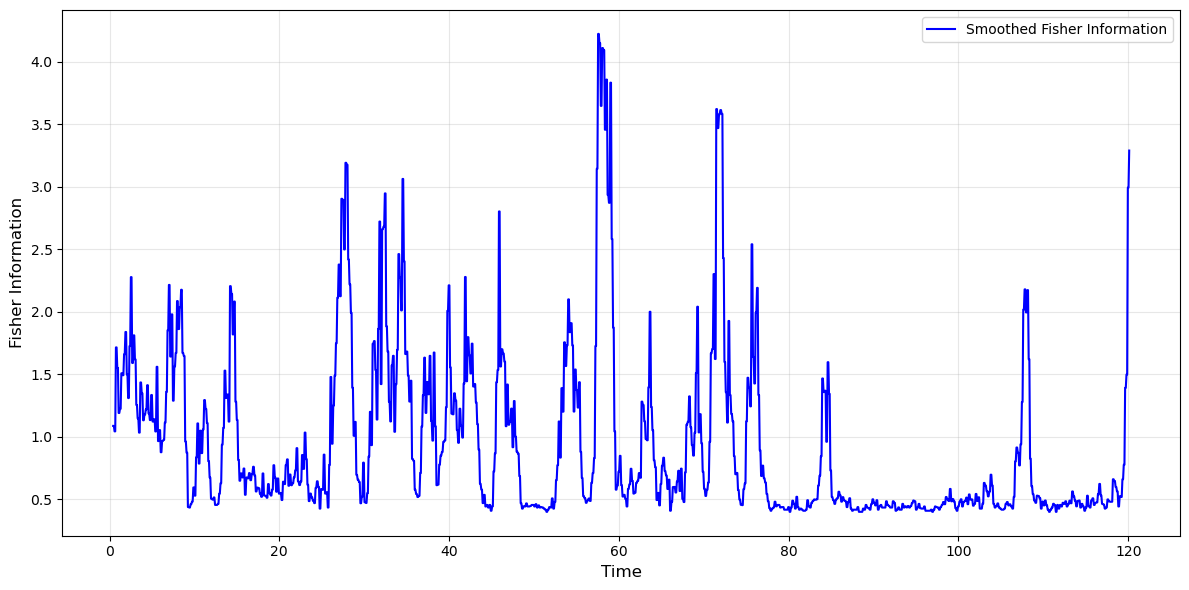

In [47]:
fig, ax = plt.subplots(figsize=(12,6))
NGRIP_lp_smooth.plot(ax=ax, color='blue',linewidth=1.5, label = 'Smoothed Fisher Information')

ax.set_xlabel('Time',fontsize=12)
ax.set_ylabel('Fisher Information',fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Step 6: Detecting Climate Transitions with LERM

The `lerm_transitions()` method performs **deterministic transition detection** on the Fisher Information series. This is a key distinction:

- **What's being analyzed**: The smoothed Fisher Information (`NGRIP_lp_smooth`)
- **Why**: Fisher Information is sensitive to dynamical changes and serves as an indicator of system transitions
- **Output**: Specific times where the system crosses critical thresholds

The LERM method identifies transitions by:
1. Computing **adaptive thresholds** from the Fisher Information distribution
- Upper threshold (95th percentile): Marks significant upward changes
- Lower threshold (5th percentile): Marks significant downward changes
2. Detecting **crossings** where Fisher Information exceeds these bounds
3. Classifying each transition as:
- **Upward (+1)**: System moving toward instability or rapid change
- **Downward (-1)**: System returning to stability

In [48]:
transitions = NGRIP_lp_smooth.lerm_transitions()
print(transitions)

Deterministic Transition Detection Results - NGRIP Ice Core Data
+----------+---------------------+----------------+------------------+---------------------+
| Method   |   Total Transitions |   Upward Jumps |   Downward Jumps | Series Label        |
+==========+=====================+================+==================+=====================+
| LERM     |                  24 |             12 |               12 | NGRIP Ice Core Data |
+----------+---------------------+----------------+------------------+---------------------+

Transition Details:
  1. Time: 9.43 kyr b2k, Direction: Upward
  2. Time: 10.43 kyr b2k, Direction: Downward
  3. Time: 12.43 kyr b2k, Direction: Upward
  4. Time: 13.43 kyr b2k, Direction: Downward
  5. Time: 15.43 kyr b2k, Direction: Upward
  6. Time: 26.43 kyr b2k, Direction: Downward
  7. Time: 29.43 kyr b2k, Direction: Upward
  8. Time: 31.43 kyr b2k, Direction: Downward
  9. Time: 36.43 kyr b2k, Direction: Upward
  10. Time: 37.43 kyr b2k, Direction: Downward

In [49]:
# Define D/O event chronologies as numpy arrays for analysis
do_events = pd.read_csv('../ammonyte/data/DO_events.csv', comment = '#')


main_do_events = do_events['main_kyr_b2k'].dropna().values
print(len(main_do_events)) # The length of main DO events 

all_do_events = do_events['all_kyr_b2k'].dropna().values
print(len(all_do_events))  # The length of all DO events

upward_mask = transitions.jump_values == 1
detected_times = transitions.jump_times[upward_mask]                          
detected_times = detected_times[~np.isnan(detected_times)]
tolerance = 0.5

results = amt.utils.evaluate_detection(detected_times, main_do_events, tolerance=0.5)   
print(results)

25
73
Detection Evaluation Metrics
Metrics calculated within tolerance = 0.5

Performance Scores:
+-----------+---------+
| Metric    |   Value |
+===========+=========+
| Precision |  0.3333 |
+-----------+---------+
| Recall    |  0.16   |
+-----------+---------+
| F1 Score  |  0.2162 |
+-----------+---------+

Detection Counts:
+-----------------+---------+
| Category        |   Count |
+=================+=========+
| True Positives  |       4 |
+-----------------+---------+
| False Positives |       8 |
+-----------------+---------+
| False Negatives |      21 |
+-----------------+---------+

Summary:
  Detected: 12 | Ground Truth: 25



## Step 7: Visualizing Detected Transitions

This dual y-axis visualization combines the Fisher Information and original climate data on a single plot. Only upward transitions are shown, since DO events are defined as abrupt warming onsets.

**Plot Elements:**

- **Black line (left y-axis)**: Original NGRIP $\delta^{18}O$ climate record (more negative = colder)
- **Green line (right y-axis)**: Smoothed Fisher Information — high values indicate the system is undergoing rapid dynamical changes
- **Red vertical lines**: Upward transitions


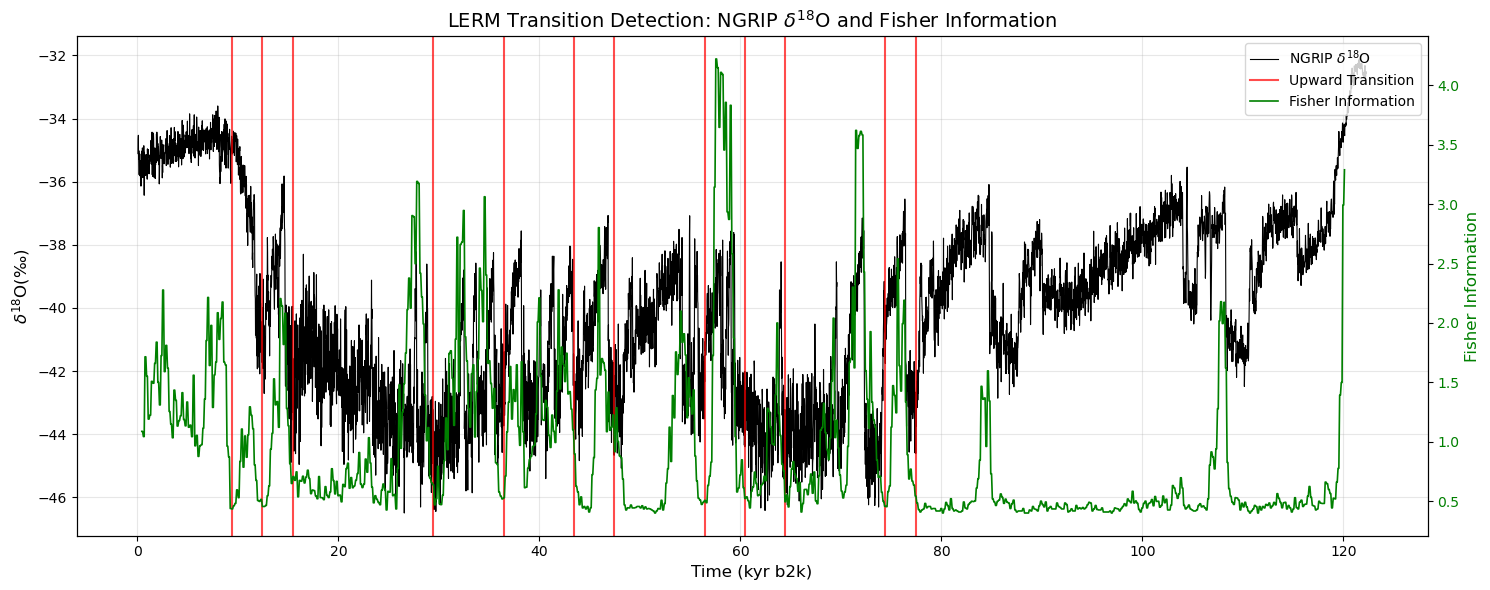

In [50]:
fig, ax1 = plt.subplots(figsize=(15,6))                                                    
ax1.plot(ngrip.time, ngrip.value, color='black', linewidth=0.8, label='NGRIP $\delta^{18}\mathrm{O}$')                                                                  
                                                                                            
ax1.set_xlabel('Time (kyr b2k)', fontsize=12)                                              
ax1.set_ylabel('$\delta^{18}\mathrm{O}(\u2030)$', fontsize=12, color='black')                      
                                                                                            
ax1.tick_params(axis='y', labelcolor='black')                                              
                                                                                            
ax2 = ax1.twinx()                                                                          
ax2.plot(NGRIP_lp_smooth.time, NGRIP_lp_smooth.value, color='green', linewidth=1.2,label='Fisher Information')                                                                
ax2.set_ylabel('Fisher Information', fontsize=12, color='green')                           
ax2.tick_params(axis='y', labelcolor='green')                                              
                                                                                                                          
first_up = True                                                                                                                                                     
for t, direction in zip(transitions.jump_times, transitions.jump_values):                  
    if direction > 0:                                                                      
        label = 'Upward Transition' if first_up else None                                  
        ax1.axvline(x=t, color='red', alpha=0.7, linewidth=1.5, label=label)               
        first_up = False                                                                                                                                 
                                                                                            
# Legend                                                                                   
lines1, labels1 = ax1.get_legend_handles_labels()                                          
lines2, labels2 = ax2.get_legend_handles_labels()                                          
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')                          
                                                                                            
ax1.set_title('LERM Transition Detection: NGRIP $\delta^{18}\mathrm{O}$ and Fisher Information', fontsize=14)                                                                 
                                                                                            
ax1.grid(True, alpha=0.3)                                                                  
plt.tight_layout()                                                                         
plt.show()

## Step 8: Alternative Detection Method (Kolmogorov-Smirnov Test)

The `kstest()` method applies the augmented **Kolmogorov-Smirnov (KS) test** to the smoothed Fisher Information series to detect statistically significant transitions. This is a complementary approach to the deterministic LERM method.

In [51]:
transitions_ks = NGRIP_lp_smooth.kstest(w_min=0.12, w_max=2.5, n_w=15,
                                        d_c=0.77, n_c=3, s_c=2, x_c=0.5)

### KS Test Results

The `print(transitions_ks)` command displays a **comprehensive summary** of all detected transitions from the KS test analysis.

The output below shows all transitions detected by the KS test, including:
- Statistical measures: D-statistics and p-values for each transition
- Transition count: 52 total (compared to 31 from LERM method)
- Direction classification: Upward vs. downward transitions

In [52]:
print(transitions_ks)

Deterministic Transition Detection Results - NGRIP Ice Core Data
+----------+---------------------+----------------+------------------+---------------------+
| Method   |   Total Transitions |   Upward Jumps |   Downward Jumps | Series Label        |
+==========+=====================+================+==================+=====================+
| KS test  |                  49 |             24 |               25 | NGRIP Ice Core Data |
+----------+---------------------+----------------+------------------+---------------------+

Transition Details:
  1. Time: 3.11 kyr b2k, Direction: Upward, d_statistics: 0.7177, p_values: < 1e-7
  2. Time: 6.79 kyr b2k, Direction: Downward, d_statistics: 0.7742, p_values: < 1e-8
  3. Time: 8.87 kyr b2k, Direction: Upward, d_statistics: 0.8125, p_values: < 1e-10
  4. Time: 11.75 kyr b2k, Direction: Upward, d_statistics: 0.2258, p_values: 0.34
  5. Time: 13.51 kyr b2k, Direction: Downward, d_statistics: 0.4567, p_values: < 1e-2
  6. Time: 14.15 kyr b2k, Dir

In [53]:
# Filter to upward transitions only (DO events are abrupt warmings)
upward_mask_ks = transitions_ks.jump_values == 1
detected_upward_ks = transitions_ks.jump_times[upward_mask_ks]
detected_upward_ks = detected_upward_ks[~np.isnan(detected_upward_ks)]

# Evaluate KS test on Fisher Information against main DO events
results_ks = amt.utils.evaluate_detection(detected_upward_ks, main_do_events, tolerance=0.5)
print(results_ks)

Detection Evaluation Metrics
Metrics calculated within tolerance = 0.5

Performance Scores:
+-----------+---------+
| Metric    |   Value |
+===========+=========+
| Precision |  0.2917 |
+-----------+---------+
| Recall    |  0.28   |
+-----------+---------+
| F1 Score  |  0.2857 |
+-----------+---------+

Detection Counts:
+-----------------+---------+
| Category        |   Count |
+=================+=========+
| True Positives  |       7 |
+-----------------+---------+
| False Positives |      17 |
+-----------------+---------+
| False Negatives |      18 |
+-----------------+---------+

Summary:
  Detected: 24 | Ground Truth: 25



### Visualizing KS Test Transitions

This dual y-axis visualization shows the KS test detected upward transitions overlaid on both the Fisher Information and original climate data. Only upward transitions are shown, as Dansgaard-Oeschger events are defined as abrupt warming onsets.

- **Black line (left y-axis)**: Original NGRIP $\delta^{18}O$ climate record
- **Green line (right y-axis)**: Smoothed Fisher Information used for transition detection
- **Red vertical lines**: Upward transitions detected by KS test          

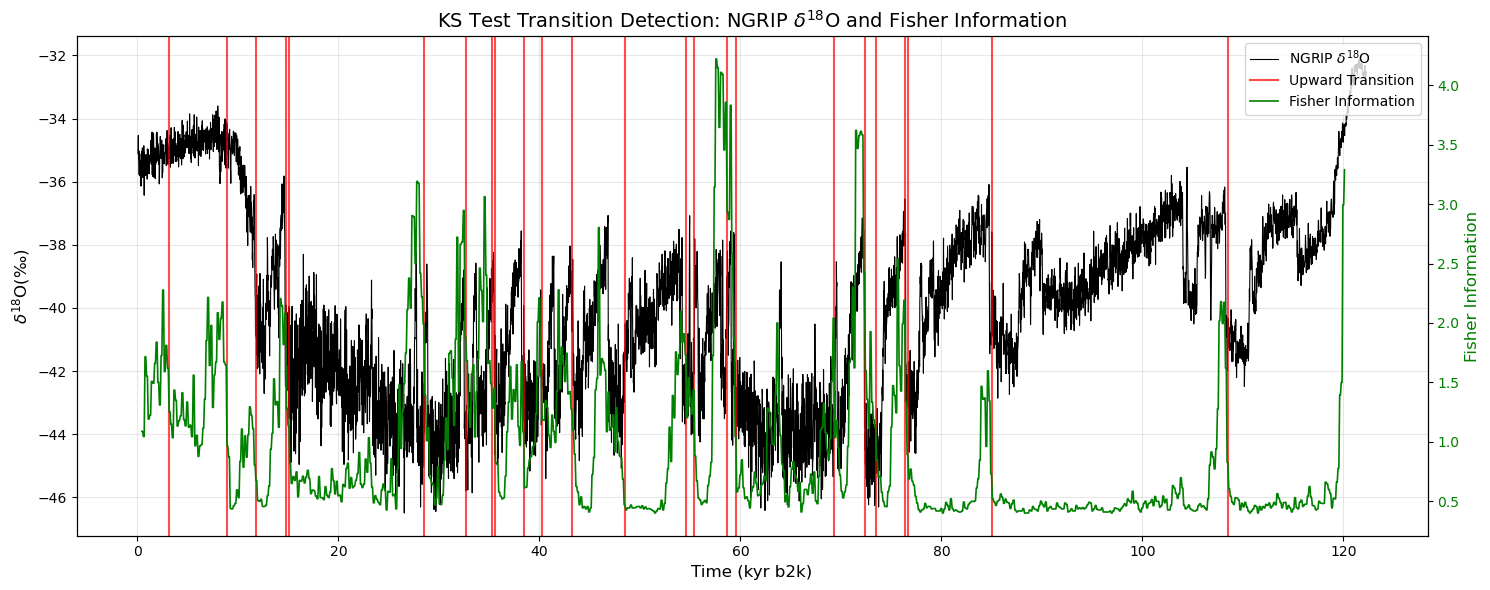

In [54]:
fig, ax1 = plt.subplots(figsize=(15,6))                                                    
ax1.plot(ngrip.time, ngrip.value, color='black', linewidth=0.8, label='NGRIP $\delta^{18}\mathrm{O}$')                                                                  
                                                                                            
ax1.set_xlabel('Time (kyr b2k)', fontsize=12)                                              
ax1.set_ylabel('$\delta^{18}\mathrm{O}(\u2030)$', fontsize=12, color='black')                      
                                                                                            
ax1.tick_params(axis='y', labelcolor='black')                                              
                                                                                            
ax2 = ax1.twinx()                                                                          
ax2.plot(NGRIP_lp_smooth.time, NGRIP_lp_smooth.value, color='green', linewidth=1.2,label='Fisher Information')                                                                
ax2.set_ylabel('Fisher Information', fontsize=12, color='green')                           
ax2.tick_params(axis='y', labelcolor='green')                                              
                                                                                                                          
first_up = True                                                                                                                                                    
for t, direction in zip(transitions_ks.jump_times, transitions_ks.jump_values):            
    if direction > 0:                                                                      
        label = 'Upward Transition' if first_up else None                                  
        ax1.axvline(x=t, color='red', alpha=0.7, linewidth=1.5, label=label)               
        first_up = False                                                                                                                                 
                                                                                            
# Legend                                                                                   
lines1, labels1 = ax1.get_legend_handles_labels()                                          
lines2, labels2 = ax2.get_legend_handles_labels()                                          
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')                          
                                                                                            
ax1.set_title('KS Test Transition Detection: NGRIP $\delta^{18}\mathrm{O}$ and Fisher Information', fontsize=14)                                                                 
                                                                                            
ax1.grid(True, alpha=0.3)                                                                  
plt.tight_layout()                                                                         
plt.show()

## Conclusion

LERM alone identifies **4 of 25 (16%)** of the DO warming events documented by [Rasmussen et al. (2014)](https://doi.org/10.1016/j.quascirev.2014.09.007), with a precision of 33% (F1 = 0.21). Applying the KS test to the Fisher Information series (Step 8) improves this to **7 of 25 (28%)**, with precision 29% (F1 = 0.28).

**Pros:** LERM operates in the system's reconstructed phase space rather than on raw values. This makes it sensitive to dynamical transitions that are invisible to amplitude-based methods, regime shifts where the climate changes state even without a large jump in $\delta^{18}\mathrm{O}(\u2030)$.

**Major drawback:** The pipeline is more complex and computationally heavier than the KS test or ruptures. Several parameters need to be set (embedding dimension, epsilon, window size), and results can vary between runs due to bootstrap sampling.

For the original method, see [James et al. (2024)](https://doi.org/10.1029/2023PA004700).